In [24]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, EpiDataOrchestrator
# get data
disease_name    = 'chickenpox'
nuts_level      = 'nuts2'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 4
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    min_date            = min_date, 
    max_date            = max_date,
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

epidata_orchestrator = (EpiDataOrchestrator(config).build())

In [25]:
from src.dataloading import BaseLineDataLoaderManager, GraphDataLoaderManager
baselinedata             = BaseLineDataLoaderManager(epidata_orchestrator)

In [ ]:
n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

graphdataloader_ig       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('identity_graph').build()
graphdataloader_gn       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('geographical_neighbors1').build()
# graphdataloader_cm11     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter14_1').build()
# graphdataloader_cm12     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter14_2').build()
# graphdataloader_cm13     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter14_3').build()
# graphdataloader_cm14     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter14_4').build()
# graphdataloader_cm21     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_1').build()
# graphdataloader_cm22     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_2').build()
# graphdataloader_cm23     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_3').build()
# graphdataloader_cm24     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_4').build()

In [27]:
from src.models import SimpleGCNModel, GATv2LSTMModel, LSTMModel

In [28]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedata)
persistence.forecast()

climateology = ClimateologyModel(baselinedata)
climateology.forecast()

climascale = ClimaScaleModel(baselinedata)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]


==                    model1                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(38, 3, 4), y=(38, 1), edge_index=(2, 38), edge_weight=(38,))
Epoch 001 train loss: 0.5033, val loss: 0.9251 ✓ (new best)
Epoch 002 train loss: 0.4718, val loss: 0.5591 ✓ (new best)
Epoch 003 train loss: 0.3898, val loss: 0.4679 ✓ (new best)
Epoch 004 train loss: 0.3779, val loss: 0.4766 (patience: 1/15)
Epoch 005 train loss: 0.3729, val loss: 0.4742 (patience: 2/15)
Epoch 006 train loss: 0.3683, val loss: 0.4693 (patience: 3/15)
Epoch 007 train loss: 0.3665, val loss: 0.4737 (patience: 4/15)
Epoch 008 train loss: 0.3603, val loss: 0.4683 (patience: 5/15)
Epoch 009 train loss: 0.3600, val loss: 0.4678 (patience: 6/15)
Epoch 010 train loss: 0.3591, val loss: 0.4691 (patience: 7/15)
Epoch 011 train loss: 0.3589, val loss: 0.4683 (patience: 8/15)
Epoch 012 train loss: 0.3589, val loss: 0.4683 (patience: 9/15)
Epoch 013 train loss: 0.3581, val loss: 0.4679 (patience

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


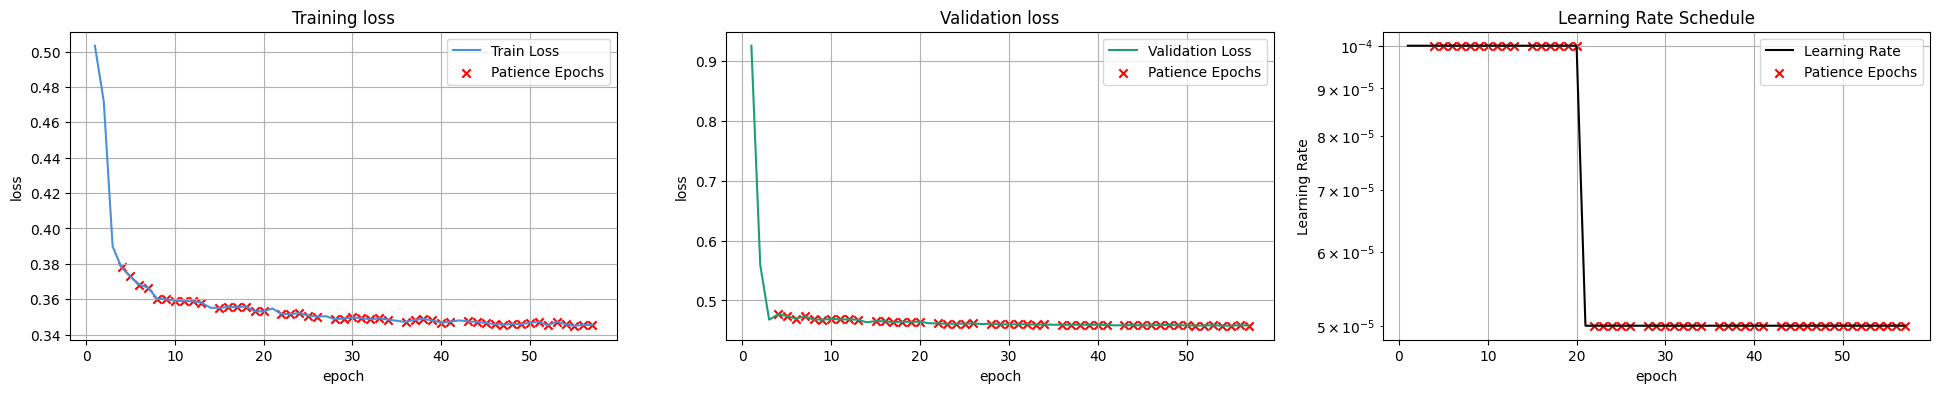

In [29]:
global_hparams = {
    'lr'    :   1e-4,
    'min_delta' : 0.001,
    'n_epochs': 250,
    'patience':15,
    'scheduler':'plateau',
    'scheduler_kwargs': {'mode': 'min', 'factor': 0.5, 'patience': 5},
    }



ml1 = GATv2LSTMModel(graphdataloader_ig, name = 'model1',verbose = 2)
ml1.set_model_hparams()
ml1.set_global_hparams(**global_hparams)
ml1.train()


==                    model2                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(38, 3, 4), y=(38, 1), edge_index=(2, 212), edge_weight=(212,))
Epoch 001 train loss: 0.6708, val loss: 1.2842 ✓ (new best)
Epoch 002 train loss: 0.6411, val loss: 0.6734 ✓ (new best)
Epoch 003 train loss: 0.5262, val loss: 0.6398 ✓ (new best)
Epoch 004 train loss: 0.5025, val loss: 0.6192 ✓ (new best)
Epoch 005 train loss: 0.4892, val loss: 0.6046 ✓ (new best)
Epoch 006 train loss: 0.4741, val loss: 0.5927 ✓ (new best)
Epoch 007 train loss: 0.4630, val loss: 0.5809 ✓ (new best)
Epoch 008 train loss: 0.4522, val loss: 0.5710 ✓ (new best)
Epoch 009 train loss: 0.4406, val loss: 0.5634 ✓ (new best)
Epoch 010 train loss: 0.4322, val loss: 0.5545 ✓ (new best)
Epoch 011 train loss: 0.4297, val loss: 0.5468 ✓ (new best)
Epoch 012 train loss: 0.4185, val loss: 0.5385 ✓ (new best)
Epoch 013 train loss: 0.4105, val loss: 0.5418 (patience: 1/15)
Epoch 014 train loss: 0.40

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


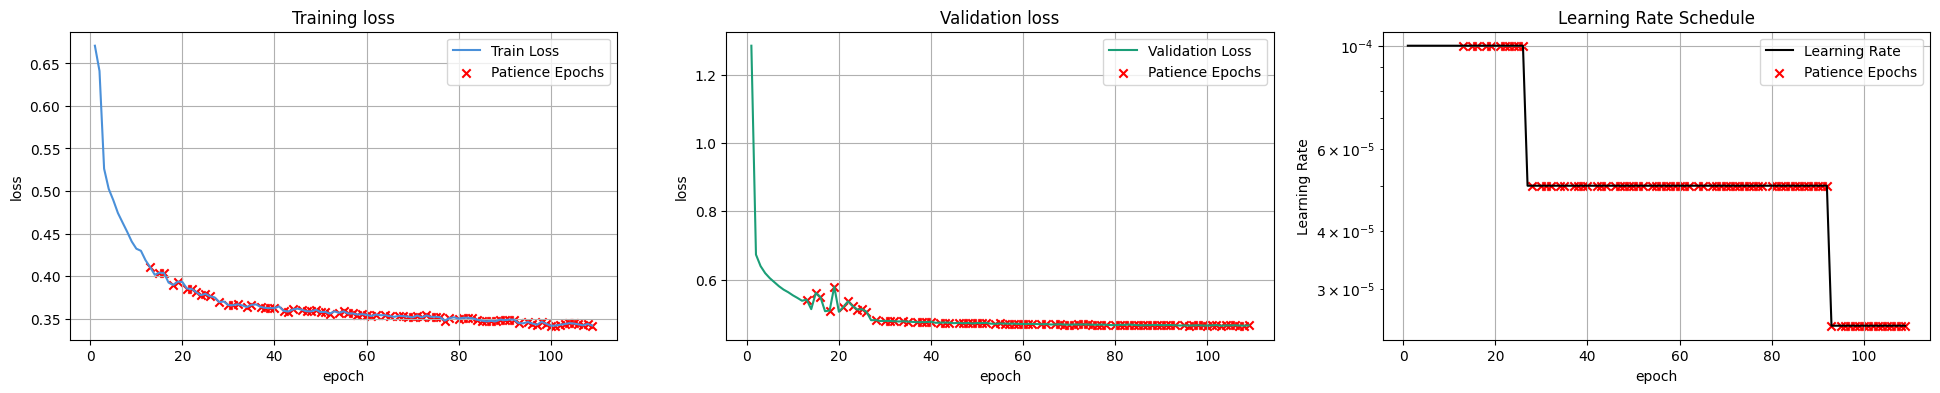

In [33]:
ml2 = GATv2LSTMModel(graphdataloader_gn,name = 'model2',verbose = 2)
ml2.set_model_hparams()
ml2.set_global_hparams(**global_hparams)
ml2.train()

In [34]:
ml1.forecast()
ml2.forecast()

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 316.66it/s]


Test loss: 0.3960
forecasted ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 317.60it/s]

Test loss: 0.4013
forecasted ✓


GATv2LSTMModel(name='model2')

computing metrics:   0%|                                                                                                                                                                | 0/8 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 12.28it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

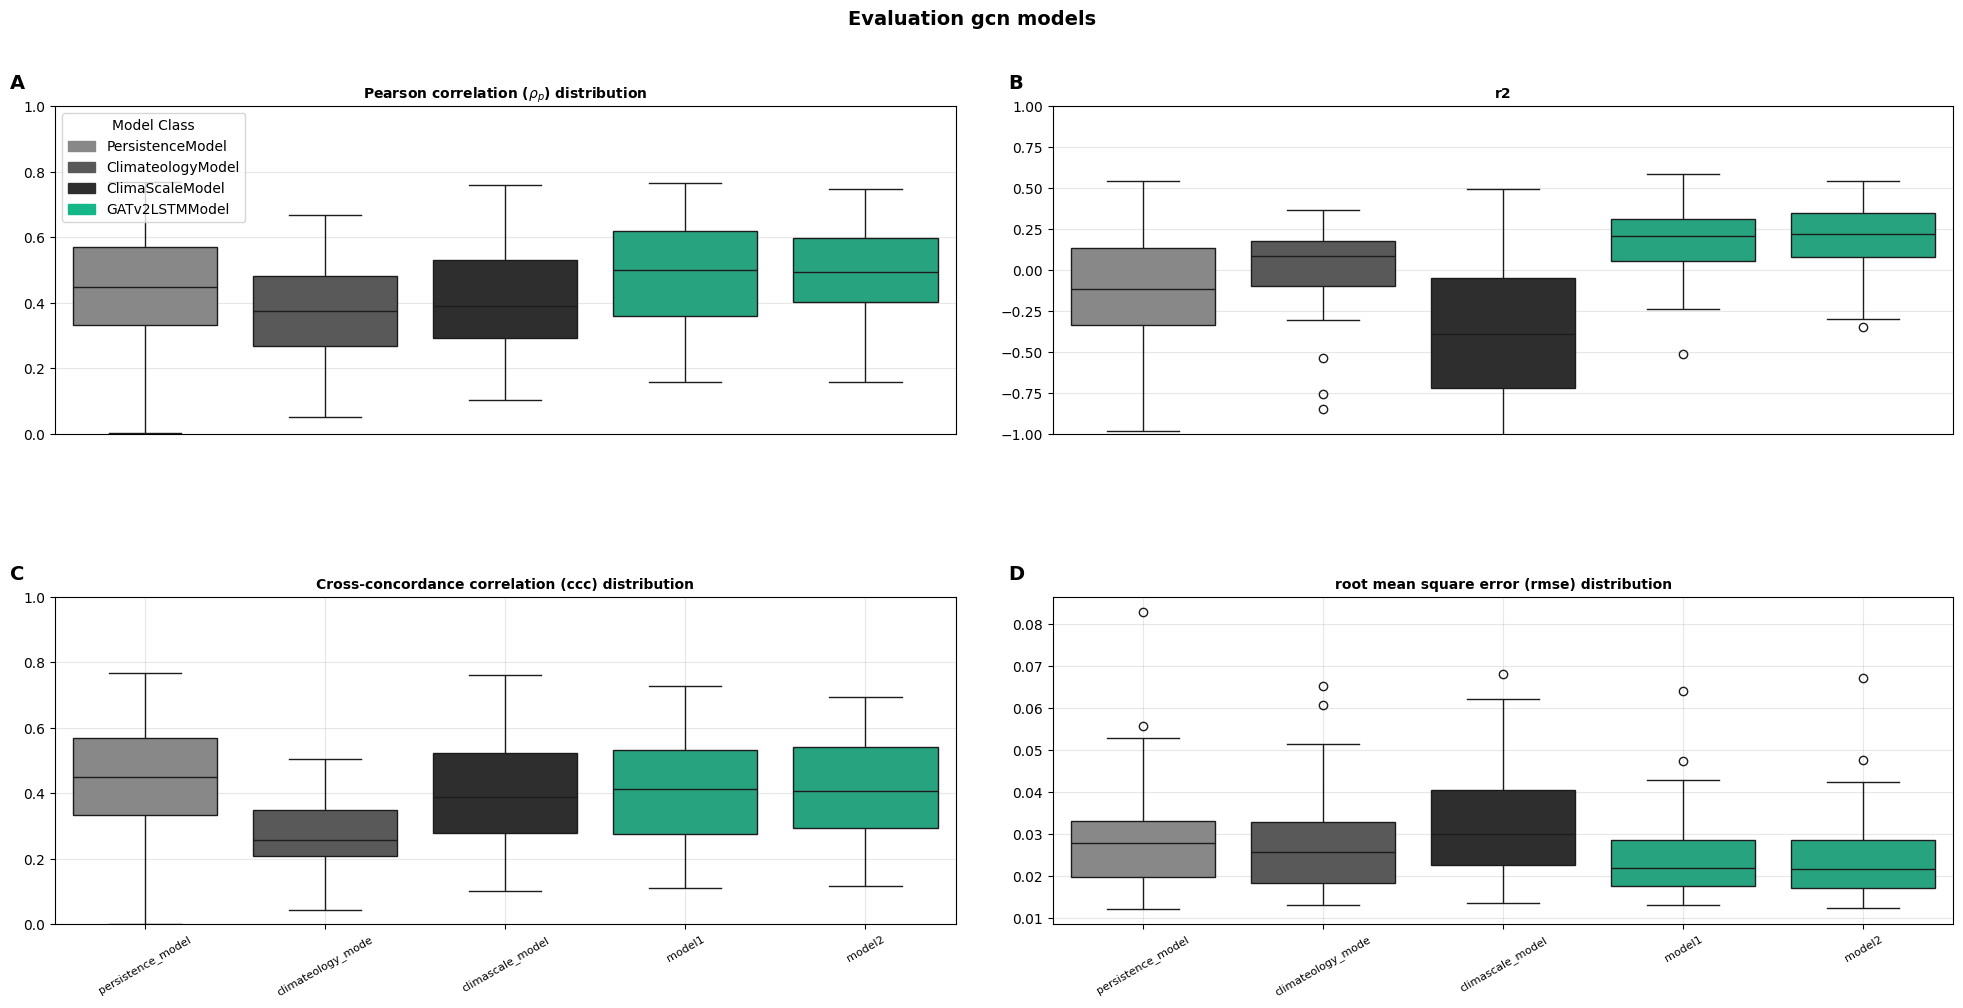

In [35]:
evaluation_experiment_sgnn = Evaluator(baseline_models + [ml1,ml2]).add_evaluation()
f_merged_raw    = evaluation_experiment_sgnn.plotter.plot_metric_compilation(metrics = ['pearson_corr','r2','ccc','rmse'], subfig_size = (8,4), plot_types = ['box','box','box','box']);

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Evaluation gcn models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('r2',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)   
    .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([-1,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,10)       
    )
f_merged.show()

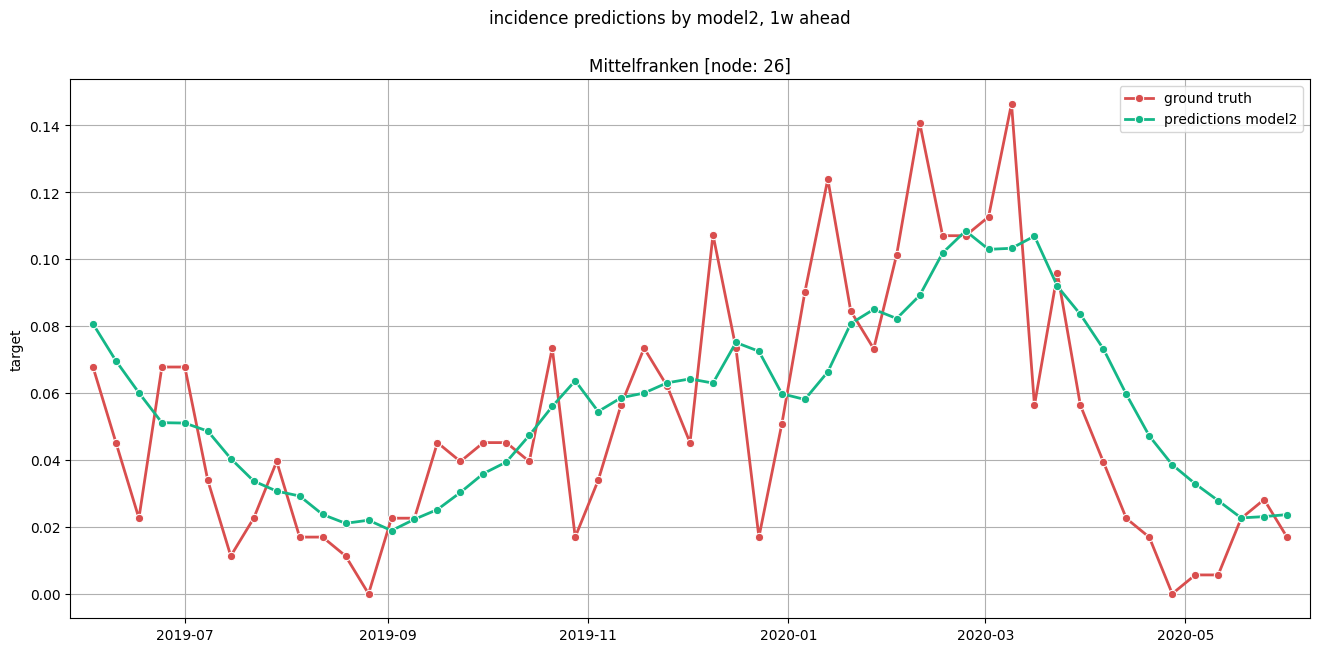

In [36]:
ml2.show_forecasts(26).show()